<a href="https://colab.research.google.com/github/alexsandoval05/Revenue-sustainability-Chrysal/blob/main/chrysal_profit_sustainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Análisis de utilidades de implementación de proyectos de sostenibilidad en Chrysal**
**OBJETIVO:** Definir rentabilidad anual en la implementación de proyectos de sostenibilidad y revisar si la inversion esta generando mayores ingresos.

## 1. 🧩 **Cargar y Explorar - Visión General Automatizado**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sales = pd.read_csv("/content/Tabla1_Chrysal_sustainability (2).csv")
marketing = pd.read_csv("/content/Tabla2_Marketing_Campaign.csv")
costs = pd.read_csv("/content/Tabla3_Costs.csv")

In [2]:
sales_clean = sales.copy()
marketing_clean = marketing.copy()
costs_clean = costs.copy()

In [3]:
# explorar datasets automatizado
datasets = {
    "SALES": sales_clean,
    "COSTS": costs_clean,
    "MARKETING": marketing_clean
}
def mostrar_heads(datasets):
    for nombre, df in datasets.items():
        print(f"\n=== {nombre} ===")
        print(df.head(10))
mostrar_heads(datasets)




=== SALES ===
  sales_order_number       fecha      pais  product_reference  campaign_id  \
0          SO-000001  2023-03-23     Kenya  Chrysal Protect Y            3   
1          SO-000002  2024-12-06  Colombia     Chrysal Grow X            1   
2          SO-000003  2024-08-19     Kenya     Chrysal Root R            4   
3          SO-000004  2024-02-05     Kenya     Chrysal Grow X            4   
4          SO-000005  2024-01-30   Holanda     Chrysal Root R            2   
5          SO-000006  2025-02-22     Kenya  Chrysal Protect Y            2   
6          SO-000007  2023-03-20   Ecuador    Chrysal Flora F            1   
7          SO-000008  2024-09-27   Ecuador     Chrysal Root R            4   
8          SO-000009  2023-07-03     Kenya    Chrysal Boost Z            4   
9          SO-000010  2023-03-27     Kenya  Chrysal Protect Y            4   

     category_product  sales_revenue  production_cost_usd  
0         Nutricional       52807.07              51180.4  
1     

In [4]:
sales_clean["Date"] = pd.to_datetime(sales_clean["fecha"], errors="coerce", utc=True)
sales_clean["Year"]  = sales_clean["Date"].dt.year
sales_clean["Month"] = sales_clean["Date"].dt.month
sales_clean.head()

,sales_order_number,fecha,pais,product_reference,campaign_id,category_product,sales_revenue,production_cost_usd,Date,Year,Month
0,SO-000001,2023-03-23,Kenya,Chrysal Protect Y,3,Nutricional,52807.07,51180.4,2023-03-23 00:00:00+00:00,2023,3
1,SO-000002,2024-12-06,Colombia,Chrysal Grow X,1,Nutricional,93797.01,50638.4,2024-12-06 00:00:00+00:00,2024,12
2,SO-000003,2024-08-19,Kenya,Chrysal Root R,4,Nutricional,77864.99,51530.7,2024-08-19 00:00:00+00:00,2024,8
3,SO-000004,2024-02-05,Kenya,Chrysal Grow X,4,Fertilizante,30000.00,51272.5,2024-02-05 00:00:00+00:00,2024,2
4,SO-000005,2024-01-30,Holanda,Chrysal Root R,2,Nutricional,70709.19,51151.0,2024-01-30 00:00:00+00:00,2024,1


In [5]:
# explorar datasets automatizado

def mostrar_info(datasets):
    for nombre, df in datasets.items():
        print(f"\n=== {nombre} ===")
        print(df.info())
mostrar_info(datasets)




=== SALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   sales_order_number   700 non-null    object             
 1   fecha                700 non-null    object             
 2   pais                 700 non-null    object             
 3   product_reference    700 non-null    object             
 4   campaign_id          700 non-null    int64              
 5   category_product     700 non-null    object             
 6   sales_revenue        700 non-null    float64            
 7   production_cost_usd  700 non-null    float64            
 8   Date                 700 non-null    datetime64[ns, UTC]
 9   Year                 700 non-null    int32              
 10  Month                700 non-null    int32              
dtypes: datetime64[ns, UTC](1), float64(2), int32(2), int64(1), object(5)


In [6]:
# explorar datasets automatizado

def mostrar_unicos(datasets):
    for nombre, df in datasets.items():
        print(f"\n=== {nombre} ===")
        print(df.nunique())
mostrar_unicos(datasets)




=== SALES ===
sales_order_number     700
fecha                  480
pais                     4
product_reference        5
campaign_id              4
category_product         5
sales_revenue          647
production_cost_usd    685
Date                   480
Year                     3
Month                   12
dtype: int64

=== COSTS ===
Sales_order_number     700
Product_reference        5
Waste_kg               664
Disposal_waste_cost    664
dtype: int64

=== MARKETING ===
Marketing_cost             4
Campaign_ID                4
Marketing_campaign_type    4
dtype: int64


In [7]:
marketing_clean["Marketing_campaign_type"].value_counts()

,count
Marketing_campaign_type,
Social Media,2
Influencers Agro,2
Field Campaign,2
Email Marketing,2


In [8]:
marketing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Marketing_cost           8 non-null      float64
 1   Campaign_ID              8 non-null      int64  
 2   Marketing_campaign_type  8 non-null      object 
dtypes: float64(1), int64(1), object(1)
memory usage: 324.0+ bytes


In [9]:
marketing_clean.duplicated().sum()

np.int64(4)

In [10]:
marketing_clean[marketing_clean.duplicated(keep=False)].sort_values(['Marketing_cost']).head()

,Marketing_cost,Campaign_ID,Marketing_campaign_type
1,3000.0,3,Influencers Agro
3,3000.0,3,Influencers Agro
6,4000.0,1,Email Marketing
7,4000.0,1,Email Marketing
2,11000.0,4,Social Media


### **Eliminacion de duplicados en marketing_clean**

In [11]:
marketing_clean  = marketing_clean.drop_duplicates(keep="first").reset_index(drop=True)
# Validación rápida (debería ser 0)
marketing_clean.duplicated().sum()

np.int64(0)

## **1.2 🧩 Identificación de problemas de calidad de datos**
Calcule la cantidad de vacios en "sales" y "costs"

In [12]:
sales_clean.isna().sum()
print('Numero de nulos',sales_clean.isna().sum())
print('Porcentaje de nulos',sales_clean.isna().mean())

Numero de nulos sales_order_number     0
fecha                  0
pais                   0
product_reference      0
campaign_id            0
category_product       0
sales_revenue          0
production_cost_usd    0
Date                   0
Year                   0
Month                  0
dtype: int64
Porcentaje de nulos sales_order_number     0.0
fecha                  0.0
pais                   0.0
product_reference      0.0
campaign_id            0.0
category_product       0.0
sales_revenue          0.0
production_cost_usd    0.0
Date                   0.0
Year                   0.0
Month                  0.0
dtype: float64


In [13]:
costs_clean.isna().sum()
print('Porcentaje de nulos',costs_clean.isna().sum())
print('Porcentaje de nulos',costs_clean.isna().mean())


Porcentaje de nulos Sales_order_number      0
Product_reference       0
Waste_kg               35
Disposal_waste_cost    35
dtype: int64
Porcentaje de nulos Sales_order_number     0.00
Product_reference      0.00
Waste_kg               0.05
Disposal_waste_cost    0.05
dtype: float64


In [14]:
costs_clean.nunique()

,0
Sales_order_number,700
Product_reference,5
Waste_kg,664
Disposal_waste_cost,664


##**CONCLUSION**
1.1- No e evidenciaron datos vacios en la tabla de "sales_clean" y solo se evidencio 5% de vacios en la tabla de "cost_clean".


In [15]:
costs_clean['Disposal_waste_cost'].isna().groupby(costs_clean['Product_reference']).sum().sort_values(ascending=False)

,Disposal_waste_cost
Product_reference,
Chrysal Flora F,11
Chrysal Protect Y,9
Chrysal Grow X,7
Chrysal Root R,5
Chrysal Boost Z,3


### **Analisis de vacios**
1.2- En la tabla anterior se observa que el producto Chrysal Flora F tiene 11 datos vacios de 35 que es aprox el 34 % de los datos. Por tal razon no son faltantes al azar sino que algo ocurrio en Chrysal Flora F que no tiene la informacion completa.

# **2- Estadistica Descriptiva**

In [16]:
print("sales",sales_clean.describe())
print("marketing",marketing_clean.describe())
print("costs",costs_clean.describe())

sales        campaign_id  sales_revenue  production_cost_usd         Year  \
count   700.000000     700.000000           700.000000   700.000000   
mean      2.364286  100167.831271         50956.599714  2023.818571   
std       1.114418   74722.284338           701.025571     0.739213   
min       1.000000   30000.000000         48799.400000  2023.000000   
25%       1.000000   57298.940000         50498.100000  2023.000000   
50%       2.000000   80902.620000         50970.550000  2024.000000   
75%       3.000000  111959.010000         51414.375000  2024.000000   
max       4.000000  500862.070000         53000.200000  2025.000000   

            Month  
count  700.000000  
mean     5.848571  
std      3.408722  
min      1.000000  
25%      3.000000  
50%      5.000000  
75%      9.000000  
max     12.000000  
marketing        Marketing_cost  Campaign_ID
count        4.000000     4.000000
mean     19500.000000     2.500000
std      27233.557731     1.290994
min       3000.000000   

## **2.1 Analisis complementario**
### **2.1.1 Realice pruebas de comparacion de media y mediana** para entender la tendencia de "Sales_revenue_USD" y "production_costs" en tabla de "sales_clean"


**HALLAZGOS:**
- **Sales Revenue USD**: posiblemente tiene un sesgo a la derecha "outlier" ya que el "max" es 5 veces que el valor del "75%"
- **Production_cost**: Posiblemente distribucion normal
- **Waste_kg** y **Disposal_waste_cost**: posiblemente tiene un sesgo a la derecha "outlier" ya que el "max" es el doble que el valor del "75%"

In [17]:
columnas_numericas_sales = sales_clean[['sales_revenue', 'production_cost_usd']]

# Include 'Disposal_waste_cost' from sales_final in the numeric columns for analysis
columnas_numericas_sales['Disposal_waste_cost'] = costs_clean['Disposal_waste_cost']

for col in columnas_numericas_sales:
    # Media y mediana de cada columna
    print(col)
    print("Promedio", columnas_numericas_sales[col].mean(),"- Mediana:", columnas_numericas_sales[col].median())
    print()

sales_revenue
Promedio 100167.83127142857 - Mediana: 80902.62

production_cost_usd
Promedio 50956.59971428571 - Mediana: 50970.55

Disposal_waste_cost
Promedio 457.38503759398486 - Mediana: 403.345



/tmp/ipykernel_1430/199210641.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  columnas_numericas_sales['Disposal_waste_cost'] = costs_clean['Disposal_waste_cost']


## **CONCLUSIONES:**

### **Diferencias entre mediana y promedio**

- Se evidencia tendencia de sesgo a la derecha para "Sales_revenue" por tal razon se debe caracterizar los valores y definir si hay outliers.
- En "production_cost_usd" NO se evidencia diferencia sifnificativa entre mediana y promedio.
- En "Disposal_waste_cost" Hay una diferencia ligera entre mediana y promedio. Es indispensable revisar el histograma para ver como se completan los datos vacios.



### 2.1.3 Realice evaluacion **agrupando por año y pais** para revisar dominancia en la columna "Sales_revenue_USD"

> Añadir blockquote



In [18]:
resumen_pais = (
    sales_clean
    .groupby(['pais'])
    .agg(
        avg_sales=('sales_revenue', 'mean'),
        count_sales=('sales_revenue', 'count'),
        desv_sales=('sales_revenue', 'std'),
        min_sales=('sales_revenue', 'min'),
        max_sales=('sales_revenue', 'max'),

    )
    .reset_index()
)
resumen_pais

,pais,avg_sales,count_sales,desv_sales,min_sales,max_sales
0,Colombia,82769.863631,179,30209.441806,30000.0,183621.39
1,Ecuador,77466.501629,178,26950.455697,30000.0,150674.64
2,Holanda,169424.290491,163,122809.722233,30000.0,500862.07
3,Kenya,77202.664778,180,28541.542200,30000.0,152800.03


**CONCLUSIONES**:

Se evidencia dominancia de tendencia de Holanda posiblemente por el efecto del Euro y la capacidad de pago mayor en Europa. La diferencia en ventas de Holanda con respecto a Colombia, Ecuador y Kenya es de **cinco veces mayor en Holanda**.

In [19]:
columnas_categoricas_1 = sales_clean[['pais','product_reference','category_product']]
columnas_categoricas_2 = marketing_clean[['Marketing_campaign_type']]

print(columnas_categoricas_1.describe())
print(columnas_categoricas_2.describe())


         pais product_reference category_product
count     700               700              700
unique      4                 5                5
top     Kenya   Chrysal Flora F     Fertilizante
freq      180               182              160
       Marketing_campaign_type
count                        4
unique                       4
top               Social Media
freq                         1


In [20]:
for col in columnas_categoricas_1:
    print(col)
    print(sales_clean[col].value_counts())
    print()

pais
pais
Kenya       180
Colombia    179
Ecuador     178
Holanda     163
Name: count, dtype: int64

product_reference
product_reference
Chrysal Flora F      182
Chrysal Boost Z      155
Chrysal Grow X       135
Chrysal Root R       126
Chrysal Protect Y    102
Name: count, dtype: int64

category_product
category_product
Fertilizante          160
Regulador de creci    145
Fungicida             136
Insecticida           130
Nutricional           129
Name: count, dtype: int64



In [21]:
print(marketing_clean["Marketing_campaign_type"].value_counts())

Marketing_campaign_type
Social Media        1
Influencers Agro    1
Field Campaign      1
Email Marketing     1
Name: count, dtype: int64


**CONCLUSION DE ANALISIS:**




De acuerdo a este conteo de columnas **categóricas dominantes**  **NO** se evidencia una afectacion especifica por alguna categoria evaluada.

## **3- Visualizacion Diagnóstica**

In [22]:
sales_paises = sales_clean[(sales_clean['pais']=='Colombia') |
                  (sales_clean['pais']=='Holanda') |
                  (sales_clean['pais']=='Kenya') |
                  (sales_clean['pais']=='Ecuador')
]
sales_paises

,sales_order_number,fecha,pais,product_reference,campaign_id,category_product,sales_revenue,production_cost_usd,Date,Year,Month
0,SO-000001,2023-03-23,Kenya,Chrysal Protect Y,3,Nutricional,52807.07,51180.4,2023-03-23 00:00:00+00:00,2023,3
1,SO-000002,2024-12-06,Colombia,Chrysal Grow X,1,Nutricional,93797.01,50638.4,2024-12-06 00:00:00+00:00,2024,12
2,SO-000003,2024-08-19,Kenya,Chrysal Root R,4,Nutricional,77864.99,51530.7,2024-08-19 00:00:00+00:00,2024,8
3,SO-000004,2024-02-05,Kenya,Chrysal Grow X,4,Fertilizante,30000.00,51272.5,2024-02-05 00:00:00+00:00,2024,2
4,SO-000005,2024-01-30,Holanda,Chrysal Root R,2,Nutricional,70709.19,51151.0,2024-01-30 00:00:00+00:00,2024,1
...,...,...,...,...,...,...,...,...,...,...,...
695,SO-000696,2023-08-20,Holanda,Chrysal Protect Y,2,Nutricional,30000.00,50935.6,2023-08-20 00:00:00+00:00,2023,8
696,SO-000697,2024-10-20,Colombia,Chrysal Protect Y,1,Nutricional,133568.62,50697.6,2024-10-20 00:00:00+00:00,2024,10
697,SO-000698,2024-06-22,Ecuador,Chrysal Boost Z,2,Nutricional,106604.79,50330.5,2024-06-22 00:00:00+00:00,2024,6
698,SO-000699,2023-02-15,Ecuador,Chrysal Boost Z,2,Fertilizante,59649.50,52441.8,2023-02-15 00:00:00+00:00,2023,2


In [23]:
costs_referencia = costs_clean[(costs_clean['Product_reference']=='Chrysal Flora F') |
                             (costs_clean['Product_reference']=='Chrysal Grow X') |
                               (costs_clean['Product_reference']=='Chrysal Root R') |
                                (costs_clean['Product_reference']=='Chrysal Protect Y') |
                               (costs_clean['Product_reference']=='Chrysal Boost Z')
]
costs_referencia


,Sales_order_number,Product_reference,Waste_kg,Disposal_waste_cost
0,SO-000001,Chrysal Grow X,750.32,375.160
1,SO-000002,Chrysal Flora F,209.94,104.970
2,SO-000003,Chrysal Flora F,882.49,441.245
3,SO-000004,Chrysal Flora F,982.56,491.280
4,SO-000005,Chrysal Grow X,582.48,291.240
...,...,...,...,...
695,SO-000696,Chrysal Boost Z,605.26,302.630
696,SO-000697,Chrysal Grow X,669.30,334.650
697,SO-000698,Chrysal Root R,846.95,423.475
698,SO-000699,Chrysal Flora F,2069.15,1034.575


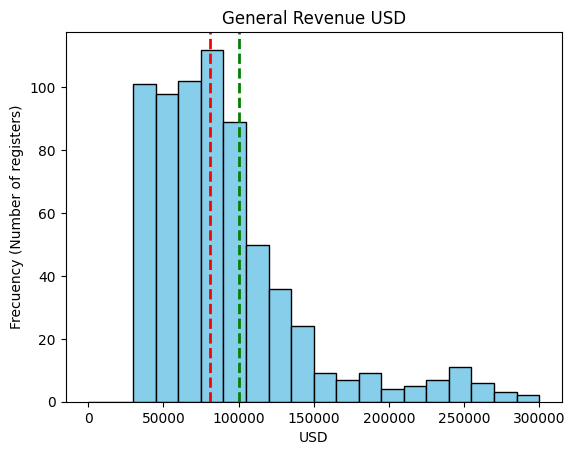

In [24]:
plt.hist(sales_clean['sales_revenue'], bins=20, color='skyblue', edgecolor='black', range=(0,300000)) # figsize=(ancho, alto)
median_sales = sales_clean['sales_revenue'].median()
average_sales = sales_clean['sales_revenue'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('General Revenue USD')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

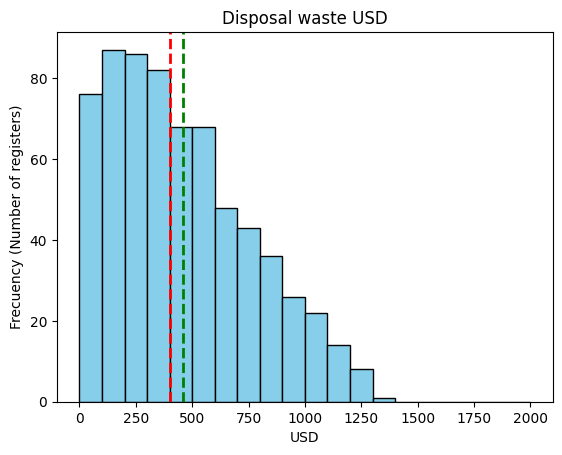

In [25]:
plt.hist(costs_clean['Disposal_waste_cost'], bins=20, color='skyblue', edgecolor='black', range=(0,2000)) # figsize=(ancho, alto)
median_sales = costs_clean['Disposal_waste_cost'].median()
average_sales = costs_clean['Disposal_waste_cost'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('Disposal waste USD')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

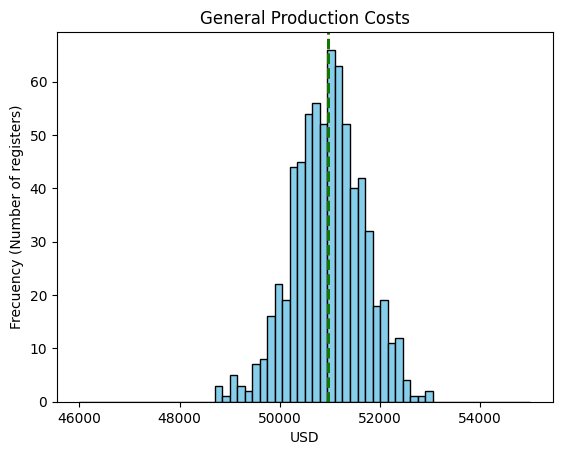

In [26]:
plt.hist(sales_clean['production_cost_usd'], bins=60, color='skyblue', edgecolor='black', range=(46000,55000)) # figsize=(ancho, alto)
median_sales = sales_clean['production_cost_usd'].median()
average_sales = sales_clean['production_cost_usd'].mean()

plt.axvline(median_sales, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(average_sales, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('General Production Costs')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

##4- Identificacion formal de Outliers
- Se realizara prueba de IQR Indice Intercuartil para entender el comportamiento de los outliers.

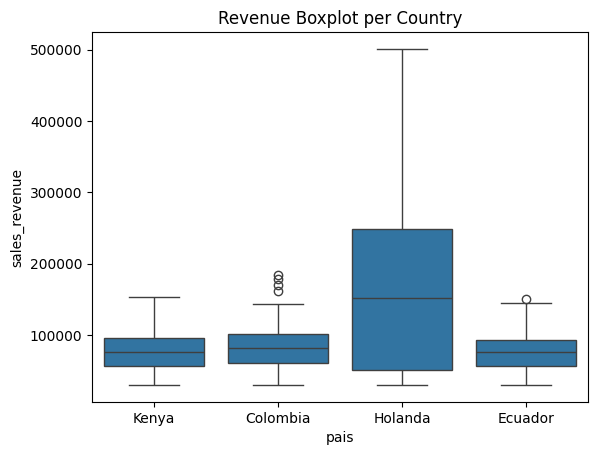

In [27]:
sns.boxplot(data=sales_paises, x="pais", y="sales_revenue")
plt.title(f'Revenue Boxplot per Country')
plt.show()


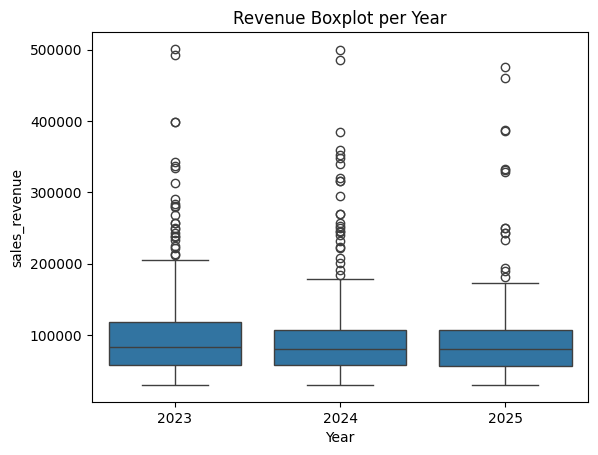

In [28]:
sns.boxplot(data=sales_paises, x="Year", y="sales_revenue")
plt.title(f'Revenue Boxplot per Year')
plt.show()


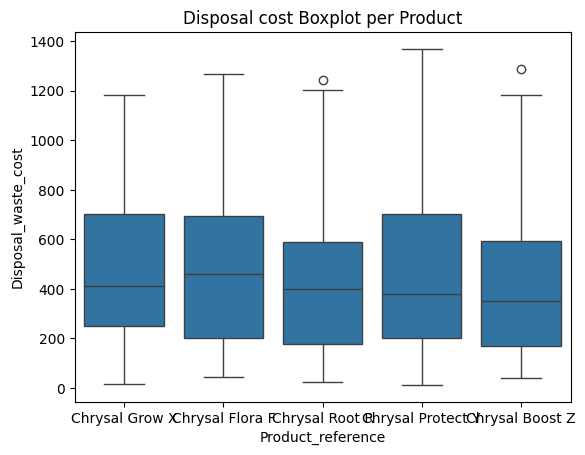

In [29]:
sns.boxplot(data=costs_referencia, x="Product_reference", y="Disposal_waste_cost")
plt.title(f'Disposal cost Boxplot per Product')
plt.show()

###**Conclusiones:**
- Teniendo en cuenta el boxplot por paises es claro que **Holanda no tiene Outliers a pesar de tener los valores mas altos y en cambio Colombia si tiene datos outliers** que pueden afectar la veracidad de sus mediciones; por tal razon se justifica eliminar outliers de Colombia.
- Los vacios de "Disposal_waste_cost" no dependenden del tipo de producto por tal razon los vacios en efecto se pueden reemplazar por la mediana por la ligera tendencia a sesgo a la derecha.

##**5 - Limpieza automatica por pipeline:**

### 5.1 Completar vacios de "Disposal_waste_cost" en la tabla "costs_clean" por la mediana
### 5.2 Quitar los outliers de "Colombia" en la tabla de "sales_clean" de la columna de "sales_revenue"

In [30]:
# Completar vacios de "Disposal waste_cost"
costs_clean['Disposal_waste_cost'] = costs_clean['Disposal_waste_cost'].fillna(costs_clean['Disposal_waste_cost'].median())
print('Porcentaje de nulos',costs_clean.isna().sum())
costs_clean.info()

Porcentaje de nulos Sales_order_number      0
Product_reference       0
Waste_kg               35
Disposal_waste_cost     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sales_order_number   700 non-null    object 
 1   Product_reference    700 non-null    object 
 2   Waste_kg             665 non-null    float64
 3   Disposal_waste_cost  700 non-null    float64
dtypes: float64(2), object(2)
memory usage: 22.0+ KB


In [31]:
# Quitar outliers de Colombia en "sales_revenue"

# Filtrar las ventas de Colombia
colombia = sales_clean[sales_clean["pais"] == "Colombia"]

# Calcular Q1, Q3 e IQR
Q1 = colombia["sales_revenue"].quantile(0.25)
Q3 = colombia["sales_revenue"].quantile(0.75)
IQR = Q3 - Q1

# Límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Limite_inferior", limite_inferior)
print("Limite_superior", limite_superior)

Limite_inferior 89.20750000001863
Limite_superior 161344.90749999997


In [32]:
sales_clean.loc[
    (sales_clean["pais"] == "Colombia") &
    (sales_clean["sales_revenue"] > limite_superior),
    "sales_revenue"
] = limite_superior
sales_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   sales_order_number   700 non-null    object             
 1   fecha                700 non-null    object             
 2   pais                 700 non-null    object             
 3   product_reference    700 non-null    object             
 4   campaign_id          700 non-null    int64              
 5   category_product     700 non-null    object             
 6   sales_revenue        700 non-null    float64            
 7   production_cost_usd  700 non-null    float64            
 8   Date                 700 non-null    datetime64[ns, UTC]
 9   Year                 700 non-null    int32              
 10  Month                700 non-null    int32              
dtypes: datetime64[ns, UTC](1), float64(2), int32(2), int64(1), object(5)
memory usage: 5

##7- Unificación tabla de interes para calculos de **% Profit y % ROI**.

**- Agregue a la tabla de "Sales_clean" la tabla de "Costs"**

In [33]:
costs_clean.rename(columns={'Sales_order_number': 'sales_order_number'}, inplace=True)
costs_clean_small = costs_clean[['sales_order_number','Disposal_waste_cost']]
costs_clean_small.head()

,sales_order_number,Disposal_waste_cost
0,SO-000001,375.160
1,SO-000002,104.970
2,SO-000003,441.245
3,SO-000004,491.280
4,SO-000005,291.240


In [34]:
sales_clean_small = sales_clean[['sales_order_number','sales_revenue','Year','production_cost_usd','pais','product_reference','campaign_id']]

sales_final = pd.merge(sales_clean_small, costs_clean_small, on=['sales_order_number'], how='left')

sales_final.head()

,sales_order_number,sales_revenue,Year,production_cost_usd,pais,product_reference,campaign_id,Disposal_waste_cost
0,SO-000001,52807.07,2023,51180.4,Kenya,Chrysal Protect Y,3,375.160
1,SO-000002,93797.01,2024,50638.4,Colombia,Chrysal Grow X,1,104.970
2,SO-000003,77864.99,2024,51530.7,Kenya,Chrysal Root R,4,441.245
3,SO-000004,30000.00,2024,51272.5,Kenya,Chrysal Grow X,4,491.280
4,SO-000005,70709.19,2024,51151.0,Holanda,Chrysal Root R,2,291.240


In [35]:
sales_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sales_order_number   700 non-null    object 
 1   sales_revenue        700 non-null    float64
 2   Year                 700 non-null    int32  
 3   production_cost_usd  700 non-null    float64
 4   pais                 700 non-null    object 
 5   product_reference    700 non-null    object 
 6   campaign_id          700 non-null    int64  
 7   Disposal_waste_cost  700 non-null    float64
dtypes: float64(3), int32(1), int64(1), object(3)
memory usage: 41.1+ KB


#**Aplica las siguientes formulas para calculo de "gross_profit" :**

- Costo total = Production_costs + Disposal_waste_cost
- Gross profit = Sales_revenus - costo_total
- % profit-margin = ( gross_profit / Sales_revenue_usd ) * 100

In [36]:
sales_final['costo_total'] = sales_final['production_cost_usd'] + sales_final['Disposal_waste_cost']
sales_final['gross_profit'] = sales_final['sales_revenue'] - sales_final['costo_total']
sales_final['margin_pct'] = (sales_final['gross_profit']) *100 / sales_final['sales_revenue']
sales_final

,sales_order_number,sales_revenue,Year,production_cost_usd,pais,product_reference,campaign_id,Disposal_waste_cost,costo_total,gross_profit,margin_pct
0,SO-000001,52807.07,2023,51180.4,Kenya,Chrysal Protect Y,3,375.160,51555.560,1251.510,2.369967
1,SO-000002,93797.01,2024,50638.4,Colombia,Chrysal Grow X,1,104.970,50743.370,43053.640,45.900866
2,SO-000003,77864.99,2024,51530.7,Kenya,Chrysal Root R,4,441.245,51971.945,25893.045,33.253770
3,SO-000004,30000.00,2024,51272.5,Kenya,Chrysal Grow X,4,491.280,51763.780,-21763.780,-72.545933
4,SO-000005,70709.19,2024,51151.0,Holanda,Chrysal Root R,2,291.240,51442.240,19266.950,27.248155
...,...,...,...,...,...,...,...,...,...,...,...
695,SO-000696,30000.00,2023,50935.6,Holanda,Chrysal Protect Y,2,302.630,51238.230,-21238.230,-70.794100
696,SO-000697,133568.62,2024,50697.6,Colombia,Chrysal Protect Y,1,334.650,51032.250,82536.370,61.793234
697,SO-000698,106604.79,2024,50330.5,Ecuador,Chrysal Boost Z,2,423.475,50753.975,55850.815,52.390530
698,SO-000699,59649.50,2023,52441.8,Ecuador,Chrysal Boost Z,2,1034.575,53476.375,6173.125,10.348997


In [37]:
profit_percent_year = (
    sales_final
    .groupby(['Year'])
    .agg(
        avg_profit_pct=('margin_pct', 'mean'),
        gross_profit_USD=('margin_pct', 'sum'),
    )
    .reset_index()
)
profit_percent_year

,Year,avg_profit_pct,gross_profit_USD
0,2023,28.580248,7602.346060
1,2024,25.810657,7614.143842
2,2025,26.619199,3700.068690


In [38]:
profit_percent_country = (
    sales_final
    .groupby(['pais'])
    .agg(
        avg_profit_pct=('margin_pct', 'mean'),
        gross_profit_USD=('margin_pct', 'sum'),
    )
    .reset_index()
)
profit_percent_country

,pais,avg_profit_pct,gross_profit_USD
0,Colombia,28.027614,5016.942931
1,Ecuador,23.495762,4182.245646
2,Holanda,35.267636,5748.624648
3,Kenya,22.048585,3968.745366


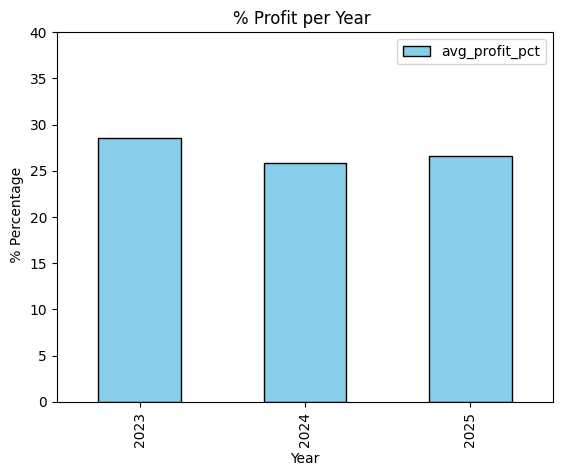

In [39]:
profit_percent_year.plot(x='Year', y=['avg_profit_pct'], kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=90)
plt.title('% Profit per Year ')
plt.ylabel(' % Percentage')
plt.ylim(0,40)
plt.show()

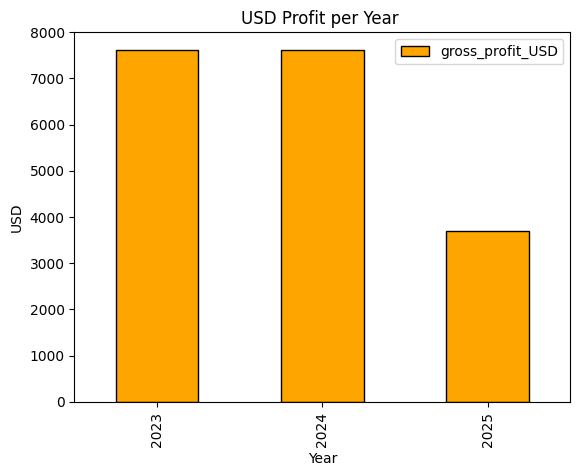

In [40]:
profit_percent_year.plot(x='Year', y=['gross_profit_USD'], kind='bar', color='orange', edgecolor='black')
plt.xticks(rotation=90)
plt.title('USD Profit per Year ')
plt.ylabel('USD')
plt.ylim(0,8000)
plt.show()

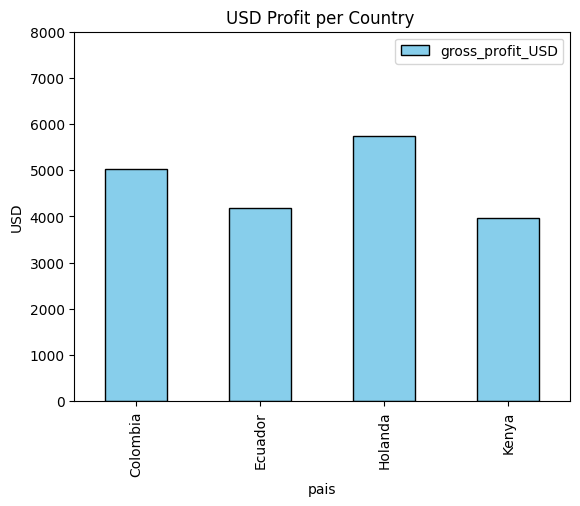

In [41]:
profit_percent_country.plot(x='pais', y=['gross_profit_USD'], kind='bar', color='skyblue', edgecolor='black')
plt.xticks(rotation=90)
plt.title('USD Profit per Country ')
plt.ylabel('USD')
plt.ylim(0,8000)
plt.show()

**🧩CONCLUSIONES:**
- Se evidencia que Holanda ha tenido **perdidas por cuantia de -U$10.000** con respecto a **utilidades de USD 7.000 que han presentado cada una de las otras sedes** como Colombia, Ecuador y Kenya posiblmente por altos costos operacionales de Holanda y nuevas tendencias del mercado floricultor.
- A nivel global las utilidades de toda la compañia fueron del 21% en 2023 y ha tenido una tendencia ha disminuir en el 2024 y 2025 con utilidadesdes del 16  y 12 % respectivamente.

In [42]:
sales_final.head()

,sales_order_number,sales_revenue,Year,production_cost_usd,pais,product_reference,campaign_id,Disposal_waste_cost,costo_total,gross_profit,margin_pct
0,SO-000001,52807.07,2023,51180.4,Kenya,Chrysal Protect Y,3,375.160,51555.560,1251.510,2.369967
1,SO-000002,93797.01,2024,50638.4,Colombia,Chrysal Grow X,1,104.970,50743.370,43053.640,45.900866
2,SO-000003,77864.99,2024,51530.7,Kenya,Chrysal Root R,4,441.245,51971.945,25893.045,33.253770
3,SO-000004,30000.00,2024,51272.5,Kenya,Chrysal Grow X,4,491.280,51763.780,-21763.780,-72.545933
4,SO-000005,70709.19,2024,51151.0,Holanda,Chrysal Root R,2,291.240,51442.240,19266.950,27.248155


In [43]:
marketing_clean.rename(columns={'Campaign_ID': 'campaign_id'}, inplace=True)
marketing_clean.head()

,Marketing_cost,campaign_id,Marketing_campaign_type
0,11000.0,4,Social Media
1,3000.0,3,Influencers Agro
2,60000.0,2,Field Campaign
3,4000.0,1,Email Marketing


## **Uno tablas para calculo de ROI, (sales_final y marketing_clean)**

- La idea es incluir costos de campaña de marketing a la tabla de sales_final con la columna en comun "campaign_id"

In [44]:
# merge con marketing

sales_final_marketing = pd.merge(sales_final, marketing_clean, on=['campaign_id'], how='left')
sales_final_marketing.head()


,sales_order_number,sales_revenue,Year,production_cost_usd,pais,product_reference,campaign_id,Disposal_waste_cost,costo_total,gross_profit,margin_pct,Marketing_cost,Marketing_campaign_type
0,SO-000001,52807.07,2023,51180.4,Kenya,Chrysal Protect Y,3,375.160,51555.560,1251.510,2.369967,3000.0,Influencers Agro
1,SO-000002,93797.01,2024,50638.4,Colombia,Chrysal Grow X,1,104.970,50743.370,43053.640,45.900866,4000.0,Email Marketing
2,SO-000003,77864.99,2024,51530.7,Kenya,Chrysal Root R,4,441.245,51971.945,25893.045,33.253770,11000.0,Social Media
3,SO-000004,30000.00,2024,51272.5,Kenya,Chrysal Grow X,4,491.280,51763.780,-21763.780,-72.545933,11000.0,Social Media
4,SO-000005,70709.19,2024,51151.0,Holanda,Chrysal Root R,2,291.240,51442.240,19266.950,27.248155,60000.0,Field Campaign


In [45]:
sales_final_marketing['ROI_pct'] = ((sales_final_marketing['gross_profit'] - sales_final_marketing['Marketing_cost']) / sales_final_marketing['Marketing_cost']) * 100
sales_final_marketing['ROI_pct'] = sales_final_marketing['ROI_pct'].round(2)
sales_final_marketing.head()

,sales_order_number,sales_revenue,Year,production_cost_usd,pais,product_reference,campaign_id,Disposal_waste_cost,costo_total,gross_profit,margin_pct,Marketing_cost,Marketing_campaign_type,ROI_pct
0,SO-000001,52807.07,2023,51180.4,Kenya,Chrysal Protect Y,3,375.160,51555.560,1251.510,2.369967,3000.0,Influencers Agro,-58.28
1,SO-000002,93797.01,2024,50638.4,Colombia,Chrysal Grow X,1,104.970,50743.370,43053.640,45.900866,4000.0,Email Marketing,976.34
2,SO-000003,77864.99,2024,51530.7,Kenya,Chrysal Root R,4,441.245,51971.945,25893.045,33.253770,11000.0,Social Media,135.39
3,SO-000004,30000.00,2024,51272.5,Kenya,Chrysal Grow X,4,491.280,51763.780,-21763.780,-72.545933,11000.0,Social Media,-297.85
4,SO-000005,70709.19,2024,51151.0,Holanda,Chrysal Root R,2,291.240,51442.240,19266.950,27.248155,60000.0,Field Campaign,-67.89


### **Agrupar ROI por pais y producto y ver pruebas de hipotesis posibles ????**

In [46]:
ROI_percent_country = (
    sales_final_marketing
    .groupby(['pais'])
    .agg(
        avg_profit_pct=('margin_pct', 'mean'),
        gross_profit_USD=('margin_pct', 'sum'),
        avg_ROI_pct=('ROI_pct', 'mean'),
    )
    .reset_index()
)
ROI_percent_country

,pais,avg_profit_pct,gross_profit_USD,avg_ROI_pct
0,Colombia,28.027614,5016.942931,267.622626
1,Ecuador,23.495762,4182.245646,215.518596
2,Holanda,35.267636,5748.624648,1637.542699
3,Kenya,22.048585,3968.745366,306.888167


In [47]:
sales_final_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sales_order_number       700 non-null    object 
 1   sales_revenue            700 non-null    float64
 2   Year                     700 non-null    int32  
 3   production_cost_usd      700 non-null    float64
 4   pais                     700 non-null    object 
 5   product_reference        700 non-null    object 
 6   campaign_id              700 non-null    int64  
 7   Disposal_waste_cost      700 non-null    float64
 8   costo_total              700 non-null    float64
 9   gross_profit             700 non-null    float64
 10  margin_pct               700 non-null    float64
 11  Marketing_cost           700 non-null    float64
 12  Marketing_campaign_type  700 non-null    object 
 13  ROI_pct                  700 non-null    float64
dtypes: float64(8), int32(1), i

In [48]:
from scipy.stats import ttest_ind

colombia = sales_final_marketing[sales_final_marketing['pais'] == 'Colombia']
holanda = sales_final_marketing[sales_final_marketing['pais'] == 'Holanda']
ecuador = sales_final_marketing[sales_final_marketing['pais'] == 'Ecuador']
kenya = sales_final_marketing[sales_final_marketing['pais'] == 'Kenya']

t_statistic, p_value = ttest_ind(colombia['ROI_pct'], kenya['ROI_pct'])
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")



T-statistic: -0.614580452586837
P-value: 0.5392233149526546


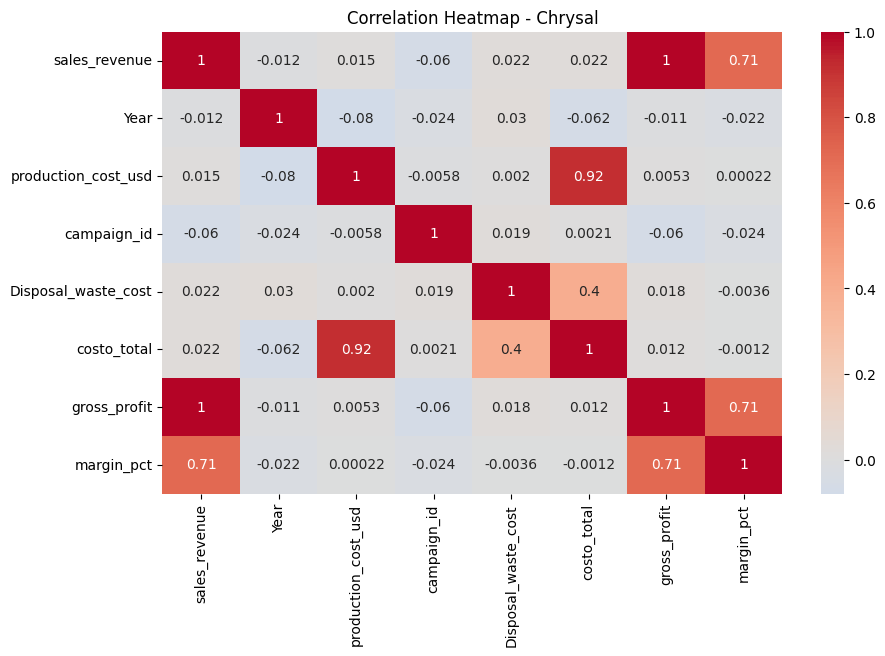

In [49]:
numeric_sales_final = sales_final.select_dtypes(include=np.number)
corr_matrix = numeric_sales_final.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Chrysal")
plt.show()

**🎯CONCLUSIONES:**
- En este analisis hay varias variables calculadas entre si como "costo_total" y "sales_revenue_usd" para calcular "gross_profit" y "margin_pct" por tal razon hay relacion entre variables porque son provenientes de calculos entre ellas mismas.
- Es importante mencionar que las ventas "sales_revenue_usd" y "production_costs" tienen una relacion fuerte positiva con un coeficiente de correlacion de 0.92
-  Se evidencia que production .

Pendiente: analisis de outliers y calculo de ROI haciendo merge de marketing